In [95]:
import pandas as pd
df = pd.read_csv("fraud_oracle.csv")

print("Shape:", df.shape)
df.head()

Shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [96]:
df.replace("?", pd.NA, inplace=True)

In [97]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


##  EDA

In [98]:
df.info()

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [99]:
print(df["FraudFound_P"].value_counts())

print("\nPercentage:")
print((df["FraudFound_P"].value_counts(normalize=True) * 100).round(2))

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Percentage:
FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64


##  Target Visualization

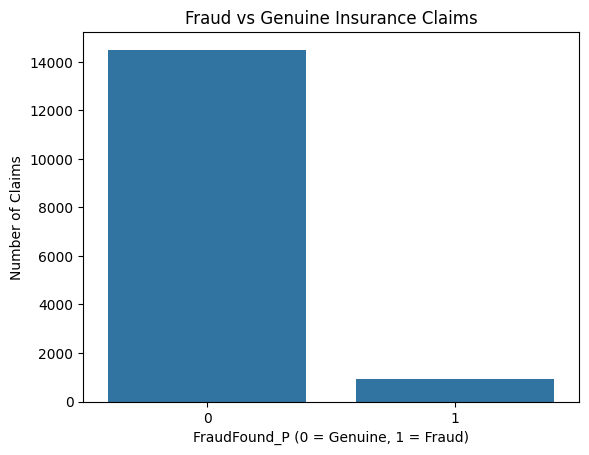

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="FraudFound_P")

plt.title("Fraud vs Genuine Insurance Claims")
plt.xlabel("FraudFound_P (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Claims")
plt.show()

##  EDA Visualizations

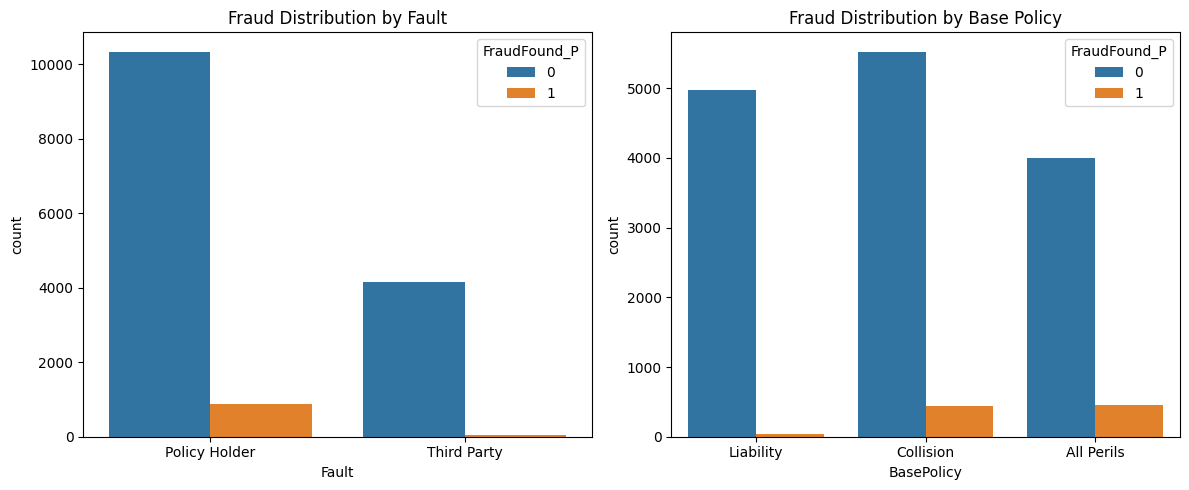

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df,x="Fault",hue="FraudFound_P",ax=axes[0])
axes[0].set_title("Fraud Distribution by Fault")

sns.countplot(data=df,x="BasePolicy",hue="FraudFound_P",ax=axes[1])
axes[1].set_title("Fraud Distribution by Base Policy")

plt.tight_layout()
plt.show()

In [102]:
X = df.drop("FraudFound_P", axis=1)
y = df["FraudFound_P"].astype(int)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (15420, 32)
Target: (15420,)


##  Feature Types

In [103]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numerical:", numerical_features)
print("\nCategorical:", categorical_features)

Numerical: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Categorical: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']


## Train/Test Split

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12336, 32)
Test: (3084, 32)


##  Pipeline

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [106]:

numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("numeric", numeric_pipeline, numerical_features),("categorical", categorical_pipeline, categorical_features)])

##  Models

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier


In [108]:

models = {"Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1),

    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.5,random_state=42),

    "XGBoost": XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,eval_metric="logloss",random_state=42,n_jobs=-1)}

## SMOTE

In [109]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


In [110]:
trained_models = {}

for name, model in models.items():

    pipeline = ImbPipeline([("preprocessing", preprocessor),("smote", SMOTE(random_state=42)),("model", model)])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(name, "trained")

Logistic Regression trained
Random Forest trained
AdaBoost trained
XGBoost trained


##  Comparing Models

In [111]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,AdaBoost,0.710117,0.139369,0.740541,0.234589,0.795791
0,Logistic Regression,0.663424,0.131374,0.821622,0.226528,0.801037
3,XGBoost,0.941634,1.000000,0.027027,0.052632,0.840445
1,Random Forest,0.940337,0.666667,0.010811,0.021277,0.831129


##  Confusion Matrices

In [112]:
from sklearn.metrics import ConfusionMatrixDisplay

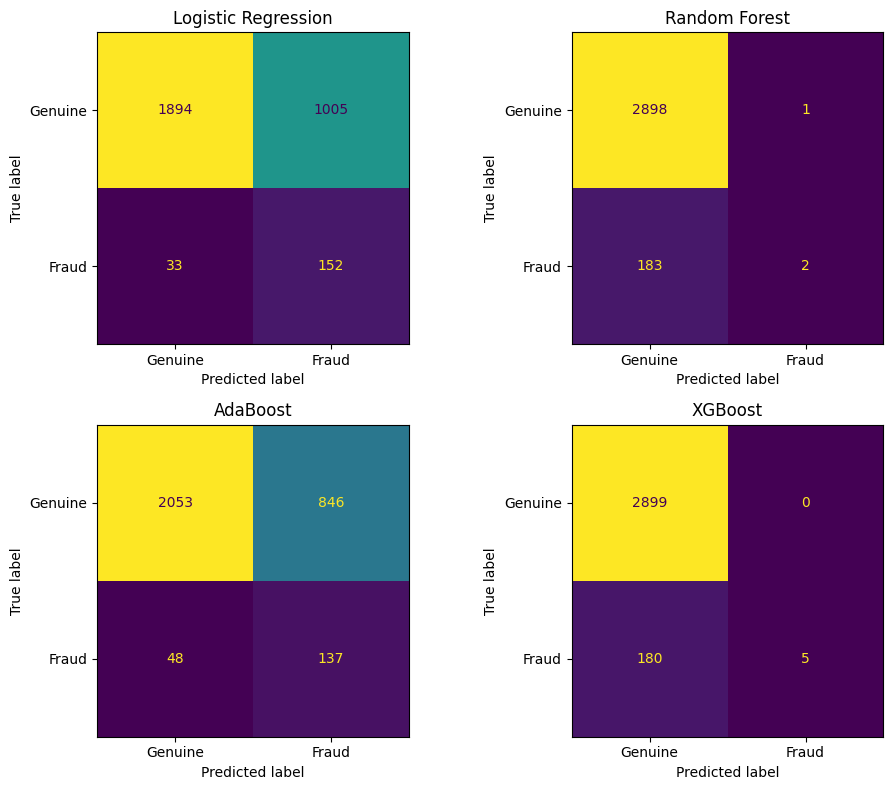

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, model) in zip(axes.ravel(), trained_models.items()):

    ConfusionMatrixDisplay.from_predictions(y_test,model.predict(X_test),display_labels=["Genuine", "Fraud"],ax=ax,colorbar=False)
    
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [114]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_spaces = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=2000,
            random_state=42
        ),
        "params": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__solver": ["lbfgs", "liblinear"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 10, 20, 30],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "AdaBoost": {
        "model": AdaBoostClassifier(
            random_state=42
        ),
        "params": {
            "model__n_estimators": [50, 100, 150, 200],
            "model__learning_rate": [0.01, 0.1, 0.5, 1.0]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [3, 4, 5, 6],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__subsample": [0.7, 0.8, 1.0],
            "model__colsample_bytree": [0.7, 0.8, 1.0]
        }
    }
}

## Hyperparameter Tuning

In [115]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", search_spaces["XGBoost"]["model"])
    ]),
    param_distributions=search_spaces["XGBoost"]["params"],
    n_iter=3,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

tuning_results = [{
    "Model": "XGBoost",
    "Best CV F1": search.best_score_,
    "Best Parameters": search.best_params_
}]
print("Best Parameters:")
print(search.best_params_)
print("Best F1:", search.best_score_)

Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}
Best F1: 0.2407706448802339


##  Tuning Results

In [116]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    "Best CV F1",
    ascending=False
)

,Model,Best CV F1,Best Parameters
0,XGBoost,0.240771,"{'model__subsample': 0.7, 'model__n_estimators..."


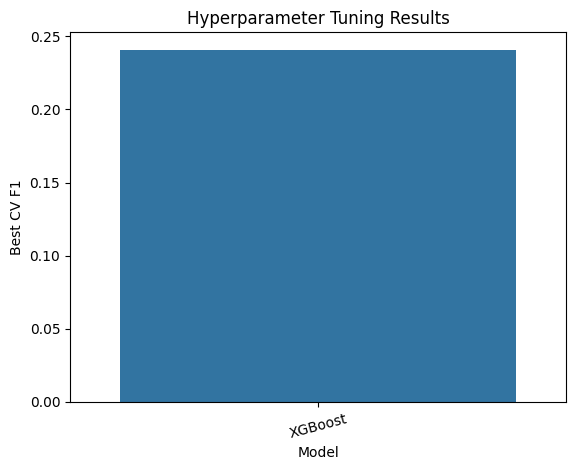

In [117]:
sns.barplot(
    data=tuning_df,
    x="Model",
    y="Best CV F1"
)

plt.title("Hyperparameter Tuning Results")
plt.xticks(rotation=15)
plt.show()

In [118]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [119]:
xgb_params = {
    "subsample": 0.7,
    "n_estimators": 100,
    "max_depth": 5,
    "learning_rate": 0.2,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1
}

In [120]:
xgb_validation = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(**xgb_params))
])

xgb_validation.fit(X_subtrain, y_subtrain)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](32,)","['Month','WeekOfMonth','DayOfWeek',...,'NumberOfCars','Year','BasePolicy']"
n_features_in_,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [121]:
from sklearn.metrics import f1_score

val_prob = xgb_validation.predict_proba(X_val)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]
scores = []

for t in thresholds:
    scores.append(f1_score(y_val, (val_prob >= t).astype(int)))

best_threshold = thresholds[scores.index(max(scores))]

print("Best Threshold:", best_threshold)
print("Best Validation F1:", round(max(scores), 4))

Best Threshold: 0.2
Best Validation F1: 0.5316


##  XGBoost Pipeline

In [122]:
final_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(**xgb_params))
])

final_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](32,)","['Month','WeekOfMonth','DayOfWeek',...,'NumberOfCars','Year','BasePolicy']"
n_features_in_,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


##  Evaluation

In [123]:
from sklearn.metrics import confusion_matrix

test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("Threshold:", best_threshold)
print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall:", round(recall_score(y_test, test_pred), 4))
print("F1:", round(f1_score(y_test, test_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, test_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

Threshold: 0.2
Accuracy: 0.9494
Precision: 0.565
Recall: 0.6811
F1: 0.6176
ROC-AUC: 0.9522

Confusion Matrix:
[[2802   97]
 [  59  126]]


## Correlation Analysis

In [124]:
encoded = pd.get_dummies(X,columns=categorical_features,dtype=int)

correlations = (encoded.corrwith(y).sort_values(key=abs, ascending=False))

correlations.head(20)

BasePolicy_Liability                 -0.154007
PolicyType_Sedan - Liability         -0.153413
VehicleCategory_Sport                -0.135903
Fault_Policy Holder                   0.131389
Fault_Third Party                    -0.131389
VehicleCategory_Sedan                 0.122182
BasePolicy_All Perils                 0.112044
PolicyType_Sedan - All Perils         0.103045
AddressChange_Claim_2 to 3 years      0.067467
PolicyType_Sport - Collision          0.050010
Make_Accura                           0.048797
PastNumberOfClaims_none               0.047680
AddressChange_Claim_under 6 months    0.046863
VehiclePrice_more than 69000          0.046806
BasePolicy_Collision                  0.043860
PastNumberOfClaims_more than 4       -0.042476
VehiclePrice_less than 20000          0.039787
PolicyType_Utility - All Perils       0.038441
VehicleCategory_Utility               0.035815
AddressChange_Claim_no change        -0.034467
dtype: float64

In [125]:
# Correlation of features with target
correlation = df.corr(numeric_only=True)["FraudFound_P"].sort_values(
    key=abs, ascending=False
)

correlation.head(10)

FraudFound_P          1.000000
Age                  -0.029741
Year                 -0.024760
PolicyNumber         -0.020345
Deductible            0.017348
WeekOfMonth          -0.011861
RepNumber            -0.007551
DriverRating          0.007266
WeekOfMonthClaimed   -0.005761
Name: FraudFound_P, dtype: float64

##  Feature Importance for frontend

In [126]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance.importances_mean
})

feature_importance.sort_values(
    "Importance",
    ascending=False
).head(10)



,Feature,Importance
15,PolicyNumber,0.176911
0,Month,0.155515
6,MonthClaimed,0.109295
11,Fault,0.085815
31,BasePolicy,0.076976
5,DayOfWeekClaimed,0.049395
17,Deductible,0.042045
28,AddressChange_Claim,0.028704
2,DayOfWeek,0.026017
21,PastNumberOfClaims,0.024370


In [127]:
top_10_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

In [128]:
selected_features = top_10_features["Feature"].tolist()

print("Selected Features:")
print(selected_features)

Selected Features:
['PolicyNumber', 'Month', 'MonthClaimed', 'Fault', 'BasePolicy', 'DayOfWeekClaimed', 'Deductible', 'AddressChange_Claim', 'DayOfWeek', 'PastNumberOfClaims']


## saving the model

In [129]:
import pickle

model_bundle = {
    "model": final_model,
    "model_name": "XGBoost",
    "threshold": float(best_threshold),
    "features": X.columns.tolist()
}

with open("best_fraud_model.pkl", "wb") as file:
    pickle.dump(model_bundle, file)

print("Model saved.")

Model saved.


##  Reloading Model 

In [130]:
with open("best_fraud_model.pkl", "rb") as file:
    loaded = pickle.load(file)

loaded_model = loaded["model"]
loaded_threshold = loaded["threshold"]

sample = X_test.iloc[[0]]

probability = loaded_model.predict_proba(sample)[0, 1]
prediction = int(probability >= loaded_threshold)

print("Fraud probability:", round(probability, 4))
print(
    "Prediction:",
    "Fraudulent" if prediction else "Genuine"
)

Fraud probability: 0.0024
Prediction: Genuine


In [131]:
# Top 10 Feature Selection Experiment

from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Find feature importance from the final full model
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

# 2. Select top 10 features
top_10_features = importance_df.head(10)["Feature"].tolist()

print("Top 10 Features:")
print(top_10_features)

# 3. Identify numerical and categorical features
top_10_num = [
    col for col in top_10_features
    if col in numerical_features
]

top_10_cat = [
    col for col in top_10_features
    if col in categorical_features
]

# 4. Preprocessing for only top 10 features
top10_preprocessor = ColumnTransformer([
    ("num", "passthrough", top_10_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), top_10_cat)
])

# 5. Train XGBoost using only top 10 features
top10_model = ImbPipeline([
    ("preprocessing", top10_preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(**xgb_params))
])

top10_model.fit(
    X_train[top_10_features],
    y_train
)

# 6. Evaluate
top10_prob = top10_model.predict_proba(
    X_test[top_10_features]
)[:, 1]

top10_pred = (top10_prob >= 0.5).astype(int)

print("\nTop 10 Feature Model Performance:")
print("Accuracy :", accuracy_score(y_test, top10_pred))
print("Precision:", precision_score(y_test, top10_pred, zero_division=0))
print("Recall   :", recall_score(y_test, top10_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, top10_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, top10_prob))

Top 10 Features:
['PolicyNumber', 'Month', 'MonthClaimed', 'Fault', 'BasePolicy', 'DayOfWeekClaimed', 'Deductible', 'PastNumberOfClaims', 'AddressChange_Claim', 'Year']

Top 10 Feature Model Performance:
Accuracy : 0.9516861219195849
Precision: 0.7903225806451613
Recall   : 0.2648648648648649
F1 Score : 0.3967611336032389
ROC-AUC  : 0.9682071170860408
